# VTX Data Sanity Check

Quick visualization of raw IMU data to verify sensor readings and damping effectiveness.

**Purpose**: Validate new recordings after firmware/hardware changes

**What to check**:
1. Orientation (roll/pitch/yaw) - Should be bounded to [-180°, 180°]
2. Accelerometer - Raw values, check for saturation/clipping
3. Gyroscope - Angular rates, check for excessive vibration noise
4. Denoising - Compare filtered vs raw to see vibration content

**After adding mechanical damping, look for**:
- Gyro readings <200 deg/s (not ±7000!)
- Orientation angles staying in reasonable ranges
- Reduced high-frequency noise in filtered signals

In [ ]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal

# Add scripts to path
sys.path.insert(0, os.path.join(os.getcwd(), '../scripts'))
from load_vtx import load_vtx_file

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

## 1. Load Data

In [3]:
# Select file to analyze
filename = 'up_hawk.vtx'  # Change this to your test file

# Load the VTX file
data = load_vtx_file(f'../data/sample-recordings/{filename}')

header = data['header']
metadata = data['metadata']
df = data['samples']

print(f"=== {filename} ===")
print(f"Duration: {header['duration']:.1f}s ({header['duration']/60:.1f} min)")
print(f"Sample rate: {header['computed_sample_rate']:.1f} Hz")
print(f"Samples: {header['sample_count']:,}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nDevice: {metadata.get('device', {}).get('name', 'Unknown')}")
print(f"Recorded: {metadata.get('session', {}).get('createdAt', 'Unknown')}")

=== up_hawk.vtx ===
Duration: 832.1s (13.9 min)
Sample rate: 49.6 Hz
Samples: 41,235

Columns: ['timestamp', 'accel_x', 'accel_y', 'accel_z', 'gyro_x', 'gyro_y', 'gyro_z', 'mag_x', 'mag_y', 'mag_z', 'time_sec']

Device: Vertex-IMU
Recorded: 2025-11-07T00:25:00.892Z


## 2. Statistics Summary

In [4]:
# Show basic stats for all sensors
print("="*60)
print("ORIENTATION (degrees)")
print("="*60)
if 'roll' in df.columns:
    for angle in ['roll', 'pitch', 'yaw']:
        values = np.degrees(df[angle].values)  # Convert radians to degrees for display
        print(f"\n{angle.upper()}:")
        print(f"  Range: [{values.min():.1f}°, {values.max():.1f}°]")
        print(f"  Mean: {values.mean():.1f}°")
        print(f"  Std: {values.std():.1f}°")
        # Check if bounded
        if values.min() >= -180 and values.max() <= 180:
            print(f"  ✓ Properly normalized [-180°, 180°]")
        else:
            print(f"  ⚠ WARNING: Values outside [-180°, 180°] range!")
else:
    print("No orientation data (roll/pitch/yaw) in this file")

print("\n" + "="*60)
print("ACCELEROMETER (m/s²)")
print("="*60)
accel_stats = df[['accel_x', 'accel_y', 'accel_z']].describe()
print(accel_stats)

print("\n" + "="*60)
print("GYROSCOPE (deg/s)")
print("="*60)
for axis in ['x', 'y', 'z']:
    col = f'gyro_{axis}'
    values = np.degrees(df[col].values)  # Convert to degrees for readability
    print(f"\nGyro {axis.upper()}:")
    print(f"  Range: [{values.min():.1f}, {values.max():.1f}] deg/s")
    print(f"  Mean: {values.mean():.1f} deg/s")
    print(f"  Std: {values.std():.1f} deg/s")
    # Check for saturation
    if abs(values.max()) > 1000 or abs(values.min()) > 1000:
        print(f"  ⚠ WARNING: Very high values! Possible vibration saturation (>1000 deg/s)")
    elif abs(values.max()) > 200 or abs(values.min()) > 200:
        print(f"  ⚠ Moderate vibration detected (>200 deg/s) - consider damping")
    else:
        print(f"  ✓ Normal range for bicycle motion")

if 'mag_x' in df.columns:
    print("\n" + "="*60)
    print("MAGNETOMETER (µT)")
    print("="*60)
    mag_stats = df[['mag_x', 'mag_y', 'mag_z']].describe()
    print(mag_stats)

ORIENTATION (degrees)
No orientation data (roll/pitch/yaw) in this file

ACCELEROMETER (m/s²)
            accel_x       accel_y       accel_z
count  41235.000000  41235.000000  41235.000000
mean       0.113110      0.367044      9.663424
std        2.615942      1.039182      2.316610
min      -31.719999    -14.190000    -16.740000
25%       -1.330000     -0.280000      8.390000
50%        0.100000      0.340000      9.630000
75%        1.660000      1.000000     10.900000
max       30.250000     13.280000     38.790001

GYROSCOPE (deg/s)

Gyro X:
  Range: [-1844.2, 1579.2] deg/s
  Mean: 2.8 deg/s
  Std: 299.4 deg/s
  ⚠ WARNING: Very high values! Possible vibration saturation (>1000 deg/s)

Gyro Y:
  Range: [-1865.7, 1439.6] deg/s
  Mean: -22.5 deg/s
  Std: 237.9 deg/s
  ⚠ WARNING: Very high values! Possible vibration saturation (>1000 deg/s)

Gyro Z:
  Range: [-2531.8, 4415.4] deg/s
  Mean: 44.5 deg/s
  Std: 615.7 deg/s
  ⚠ WARNING: Very high values! Possible vibration saturation (>10

## 3. Orientation Visualization

If this recording has euler angles, visualize them to check normalization.

In [5]:
if 'roll' in df.columns:
    # Convert to degrees for visualization
    df['roll_deg'] = np.degrees(df['roll'])
    df['pitch_deg'] = np.degrees(df['pitch'])
    df['yaw_deg'] = np.degrees(df['yaw'])
    
    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
    
    # Roll
    axes[0].plot(df['time_sec'], df['roll_deg'], linewidth=1, alpha=0.8, color='blue')
    axes[0].axhline(y=0, color='k', linestyle='-', alpha=0.3, linewidth=0.5)
    axes[0].axhline(y=180, color='r', linestyle='--', alpha=0.3, linewidth=0.5)
    axes[0].axhline(y=-180, color='r', linestyle='--', alpha=0.3, linewidth=0.5)
    axes[0].set_ylabel('Roll (°)')
    axes[0].set_title('Roll - Bike Lean (should stay within ±45° typically)')
    axes[0].set_ylim(-180, 180)
    axes[0].grid(True, alpha=0.3)
    
    # Pitch
    axes[1].plot(df['time_sec'], df['pitch_deg'], linewidth=1, alpha=0.8, color='green')
    axes[1].axhline(y=0, color='k', linestyle='-', alpha=0.3, linewidth=0.5)
    axes[1].axhline(y=180, color='r', linestyle='--', alpha=0.3, linewidth=0.5)
    axes[1].axhline(y=-180, color='r', linestyle='--', alpha=0.3, linewidth=0.5)
    axes[1].set_ylabel('Pitch (°)')
    axes[1].set_title('Pitch - Forward/Back Tilt (hills, should stay within ±20° typically)')
    axes[1].set_ylim(-180, 180)
    axes[1].grid(True, alpha=0.3)
    
    # Yaw
    axes[2].plot(df['time_sec'], df['yaw_deg'], linewidth=1, alpha=0.8, color='red')
    axes[2].axhline(y=0, color='k', linestyle='-', alpha=0.3, linewidth=0.5)
    axes[2].axhline(y=180, color='r', linestyle='--', alpha=0.3, linewidth=0.5)
    axes[2].axhline(y=-180, color='r', linestyle='--', alpha=0.3, linewidth=0.5)
    axes[2].set_ylabel('Yaw (°)')
    axes[2].set_title('Yaw - Heading/Direction (compass)')
    axes[2].set_ylim(-180, 180)
    axes[2].grid(True, alpha=0.3)
    
    # All combined
    axes[3].plot(df['time_sec'], df['roll_deg'], linewidth=1, alpha=0.7, color='blue', label='Roll')
    axes[3].plot(df['time_sec'], df['pitch_deg'], linewidth=1, alpha=0.7, color='green', label='Pitch')
    axes[3].plot(df['time_sec'], df['yaw_deg'], linewidth=1, alpha=0.7, color='red', label='Yaw')
    axes[3].axhline(y=0, color='k', linestyle='-', alpha=0.3, linewidth=0.5)
    axes[3].set_ylabel('Angle (°)')
    axes[3].set_xlabel('Time (seconds)')
    axes[3].set_title('All Orientation Angles')
    axes[3].legend(loc='upper right')
    axes[3].set_ylim(-180, 180)
    axes[3].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Check for wrapping issues
    print("\n" + "="*60)
    print("ORIENTATION QUALITY CHECK")
    print("="*60)
    
    for angle in ['roll', 'pitch', 'yaw']:
        values = df[f'{angle}_deg'].values
        diffs = np.abs(np.diff(values))
        large_jumps = (diffs > 90).sum()
        max_jump = diffs.max()
        
        print(f"\n{angle.upper()}:")
        print(f"  Max discontinuity: {max_jump:.1f}°")
        print(f"  Large jumps (>90°): {large_jumps}")
        
        if large_jumps > len(values) * 0.01:  # More than 1% of samples
            print(f"  ⚠ WARNING: Many discontinuities - possible vibration corruption")
        elif large_jumps > 0:
            print(f"  ⚠ Some boundary crossings (normal at ±180° wrap point)")
        else:
            print(f"  ✓ Smooth, no large discontinuities")
else:
    print("No orientation data in this file")

No orientation data in this file


## 4. Raw Accelerometer & Gyroscope

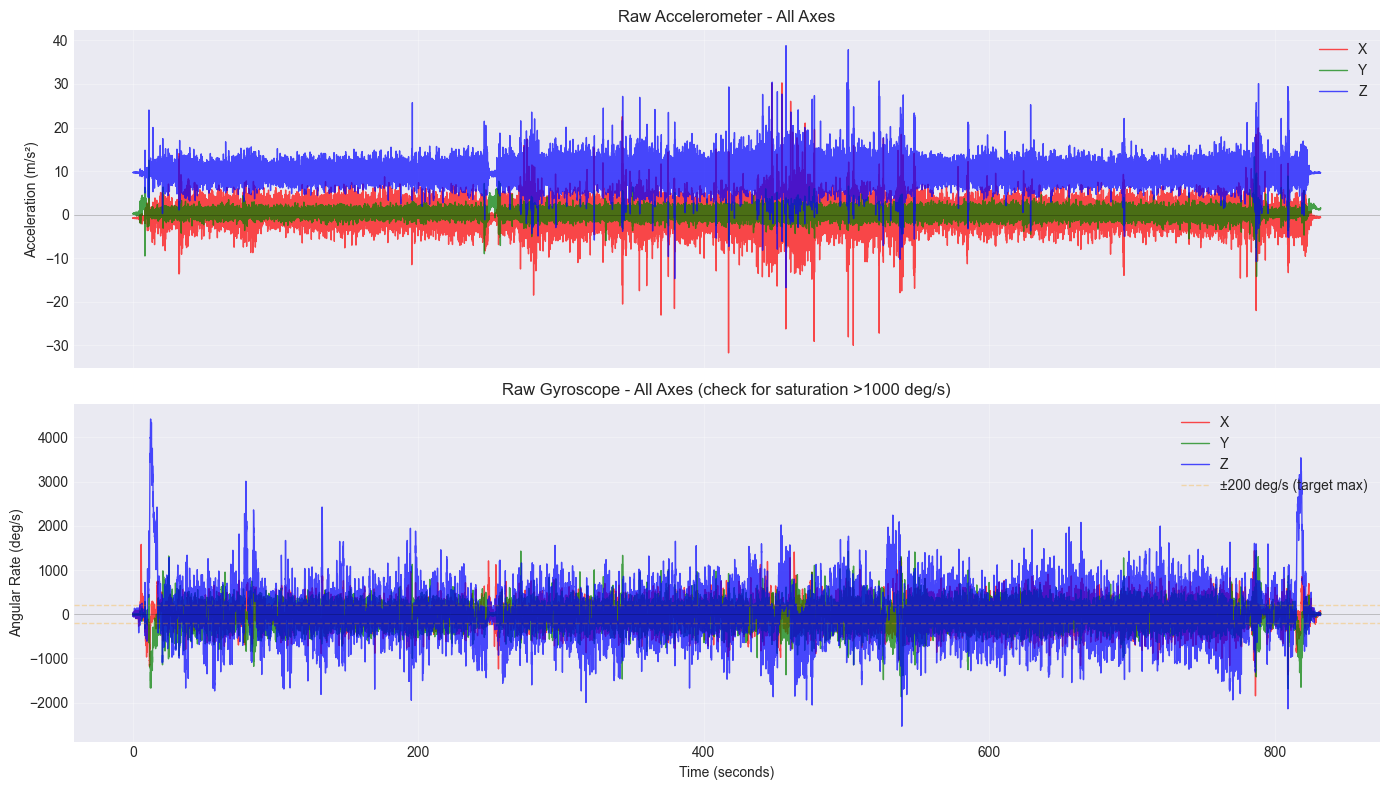

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Accelerometer
for axis, color in zip(['x', 'y', 'z'], ['red', 'green', 'blue']):
    axes[0].plot(df['time_sec'], df[f'accel_{axis}'], 
                label=f'{axis.upper()}', alpha=0.7, linewidth=1, color=color)
axes[0].axhline(y=0, color='k', linestyle='-', alpha=0.3, linewidth=0.5)
axes[0].set_ylabel('Acceleration (m/s²)')
axes[0].set_title('Raw Accelerometer - All Axes')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Gyroscope (convert to deg/s)
for axis, color in zip(['x', 'y', 'z'], ['red', 'green', 'blue']):
    axes[1].plot(df['time_sec'], np.degrees(df[f'gyro_{axis}']), 
                label=f'{axis.upper()}', alpha=0.7, linewidth=1, color=color)
axes[1].axhline(y=0, color='k', linestyle='-', alpha=0.3, linewidth=0.5)
# Add reference lines for "reasonable" bike rotation
axes[1].axhline(y=200, color='orange', linestyle='--', alpha=0.3, linewidth=1, label='±200 deg/s (target max)')
axes[1].axhline(y=-200, color='orange', linestyle='--', alpha=0.3, linewidth=1)
axes[1].set_ylabel('Angular Rate (deg/s)')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_title('Raw Gyroscope - All Axes (check for saturation >1000 deg/s)')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Denoising Comparison

Compare different filtering methods to see how much noise is present.

In [7]:
def butterworth_lowpass(data, cutoff=5.0, sample_rate=None, order=4):
    """Apply Butterworth low-pass filter"""
    nyquist = sample_rate / 2
    normal_cutoff = cutoff / nyquist
    b, a = signal.butter(order, normal_cutoff, btype='low', analog=False)
    return signal.filtfilt(b, a, data)

def moving_average(data, window=10):
    """Simple moving average"""
    return pd.Series(data).rolling(window=window, center=True).mean().values

sample_rate = header['computed_sample_rate']
print(f"Sample rate: {sample_rate:.1f} Hz")
print(f"Nyquist frequency: {sample_rate/2:.1f} Hz")

Sample rate: 49.6 Hz
Nyquist frequency: 24.8 Hz


### 5.1 Orientation Denoising

In [8]:
if 'roll' in df.columns:
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    
    for idx, angle in enumerate(['roll', 'pitch', 'yaw']):
        raw = df[f'{angle}_deg'].values
        
        # Apply filters
        butter_2hz = butterworth_lowpass(raw, cutoff=2.0, sample_rate=sample_rate, order=4)
        butter_5hz = butterworth_lowpass(raw, cutoff=5.0, sample_rate=sample_rate, order=4)
        mavg_20 = moving_average(raw, window=20)
        
        # Plot
        axes[idx].plot(df['time_sec'], raw, label='Raw', linewidth=0.5, alpha=0.4, color='gray')
        axes[idx].plot(df['time_sec'], butter_2hz, label='Butterworth 2Hz', linewidth=1.5, alpha=0.8)
        axes[idx].plot(df['time_sec'], butter_5hz, label='Butterworth 5Hz', linewidth=1.5, alpha=0.8)
        axes[idx].plot(df['time_sec'], mavg_20, label='Moving Avg (20 samples)', linewidth=1.5, alpha=0.8)
        
        axes[idx].axhline(y=0, color='k', linestyle='-', alpha=0.3, linewidth=0.5)
        axes[idx].set_ylabel(f'{angle.capitalize()} (°)')
        axes[idx].set_title(f'{angle.capitalize()} - Denoising Comparison')
        axes[idx].legend(loc='upper right')
        axes[idx].grid(True, alpha=0.3)
    
    axes[-1].set_xlabel('Time (seconds)')
    plt.tight_layout()
    plt.show()
else:
    print("No orientation data to denoise")

No orientation data to denoise


### 5.2 Accelerometer Denoising

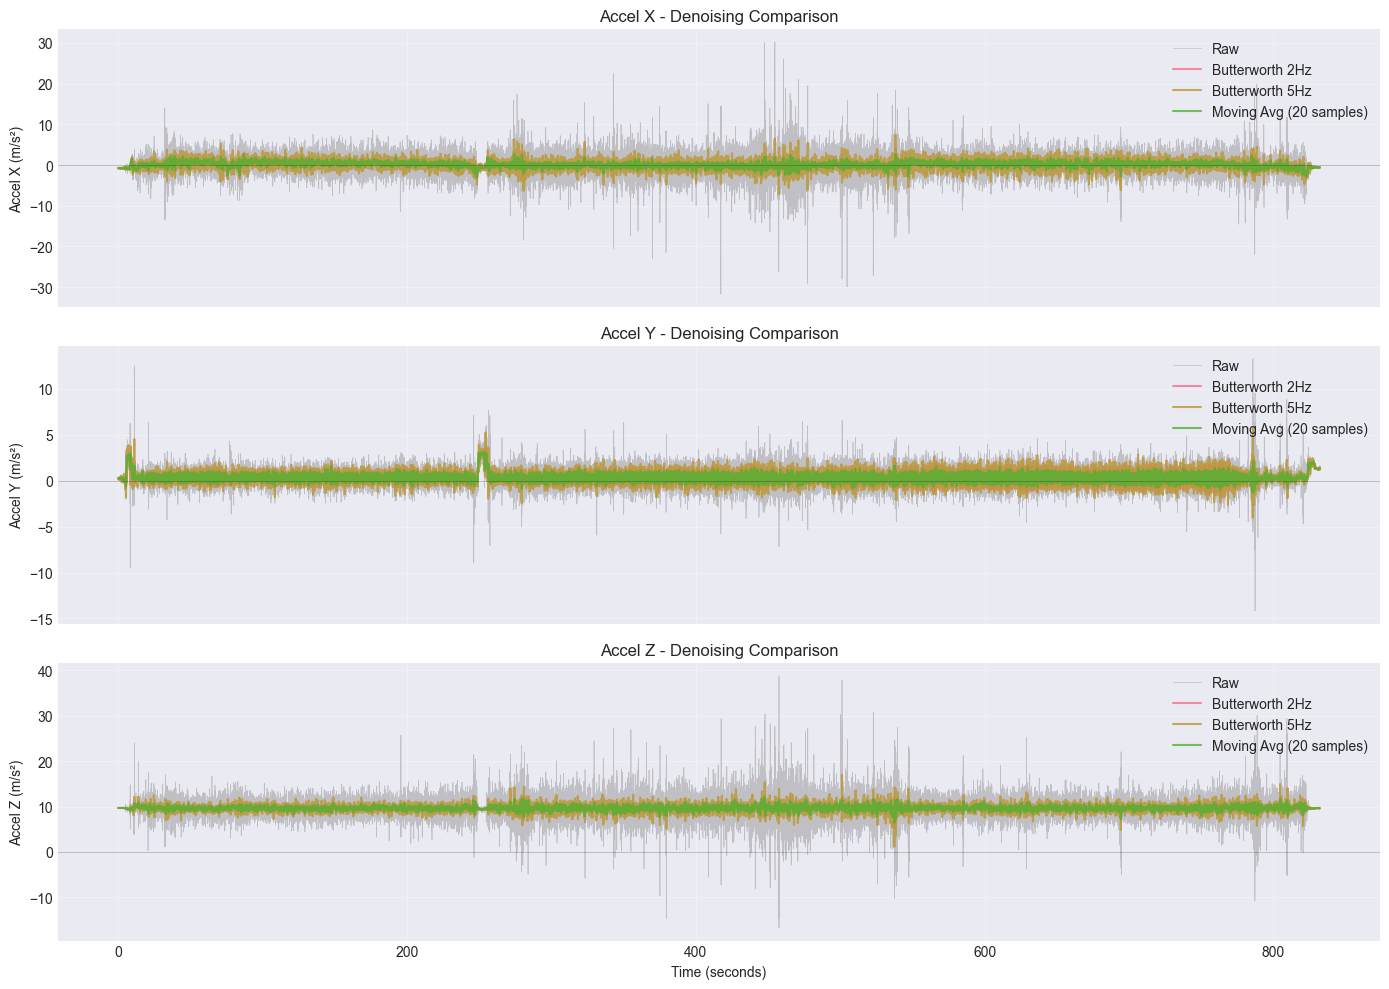

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for idx, axis in enumerate(['x', 'y', 'z']):
    raw = df[f'accel_{axis}'].values
    
    # Apply filters
    butter_2hz = butterworth_lowpass(raw, cutoff=2.0, sample_rate=sample_rate, order=4)
    butter_5hz = butterworth_lowpass(raw, cutoff=5.0, sample_rate=sample_rate, order=4)
    mavg_20 = moving_average(raw, window=20)
    
    # Plot
    axes[idx].plot(df['time_sec'], raw, label='Raw', linewidth=0.5, alpha=0.4, color='gray')
    axes[idx].plot(df['time_sec'], butter_2hz, label='Butterworth 2Hz', linewidth=1.5, alpha=0.8)
    axes[idx].plot(df['time_sec'], butter_5hz, label='Butterworth 5Hz', linewidth=1.5, alpha=0.8)
    axes[idx].plot(df['time_sec'], mavg_20, label='Moving Avg (20 samples)', linewidth=1.5, alpha=0.8)
    
    axes[idx].axhline(y=0, color='k', linestyle='-', alpha=0.3, linewidth=0.5)
    axes[idx].set_ylabel(f'Accel {axis.upper()} (m/s²)')
    axes[idx].set_title(f'Accel {axis.upper()} - Denoising Comparison')
    axes[idx].legend(loc='upper right')
    axes[idx].grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (seconds)')
plt.tight_layout()
plt.show()

### 5.3 Gyroscope Denoising

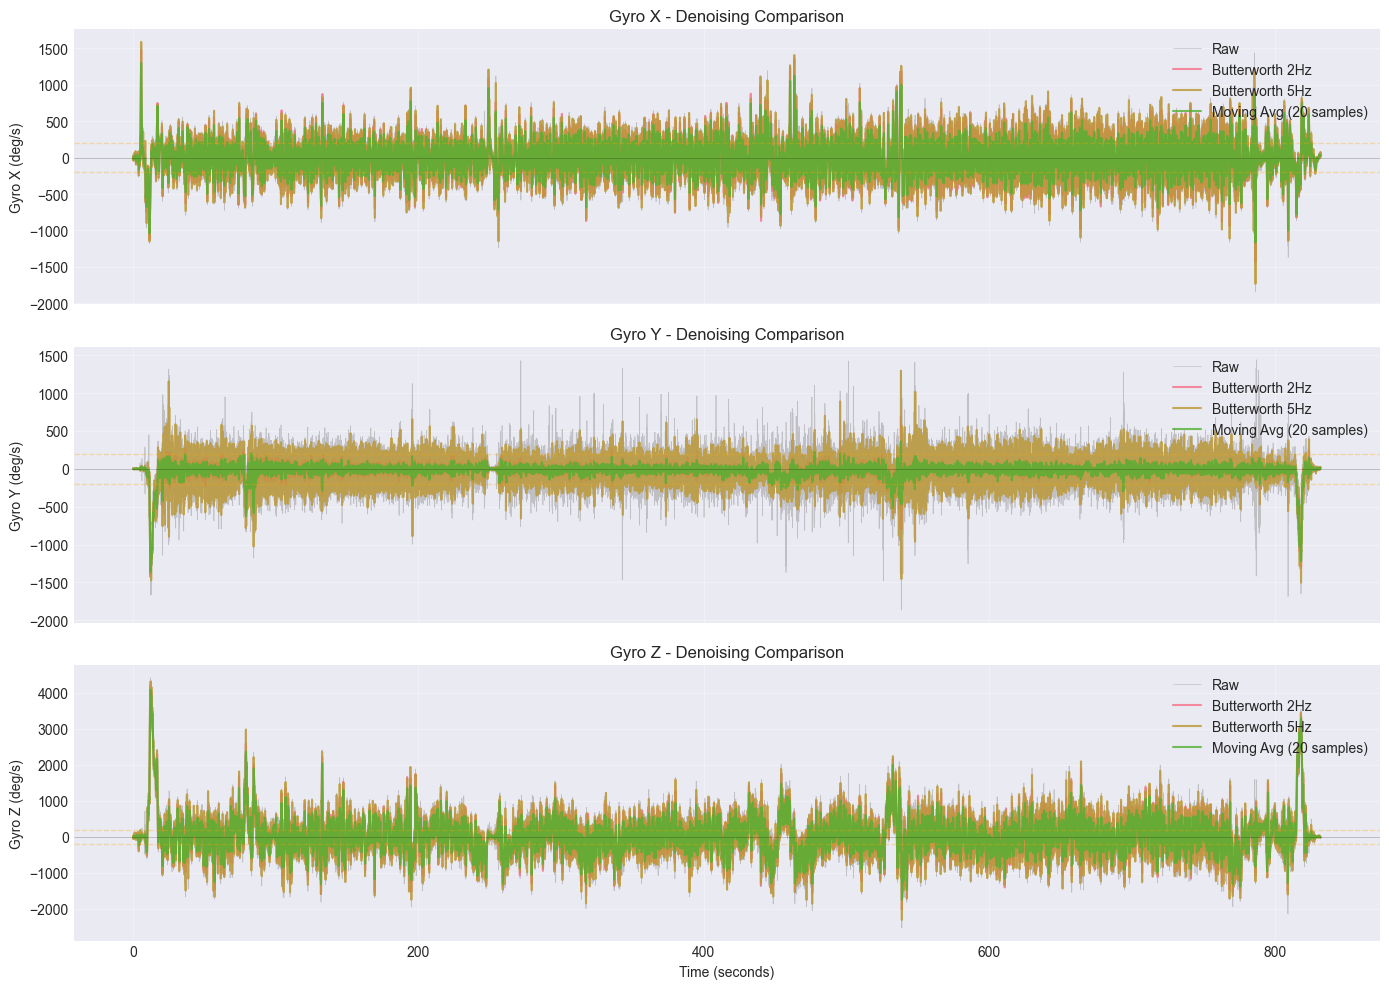


DENOISING EFFECTIVENESS

Compare raw (gray) vs filtered signals:
- Large difference = high noise (vibration issue)
- Small difference = clean signal (good damping)

After adding mechanical damping, you should see:
✓ Raw and filtered signals closer together
✓ Gyro staying within ±200 deg/s
✓ Smoother orientation angles


In [11]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for idx, axis in enumerate(['x', 'y', 'z']):
    raw = np.degrees(df[f'gyro_{axis}'].values)  # Convert to deg/s
    
    # Apply filters
    butter_2hz = butterworth_lowpass(raw, cutoff=2.0, sample_rate=sample_rate, order=4)
    butter_5hz = butterworth_lowpass(raw, cutoff=5.0, sample_rate=sample_rate, order=4)
    mavg_20 = moving_average(raw, window=20)
    
    # Plot
    axes[idx].plot(df['time_sec'], raw, label='Raw', linewidth=0.5, alpha=0.4, color='gray')
    axes[idx].plot(df['time_sec'], butter_2hz, label='Butterworth 2Hz', linewidth=1.5, alpha=0.8)
    axes[idx].plot(df['time_sec'], butter_5hz, label='Butterworth 5Hz', linewidth=1.5, alpha=0.8)
    axes[idx].plot(df['time_sec'], mavg_20, label='Moving Avg (20 samples)', linewidth=1.5, alpha=0.8)
    
    axes[idx].axhline(y=0, color='k', linestyle='-', alpha=0.3, linewidth=0.5)
    axes[idx].axhline(y=200, color='orange', linestyle='--', alpha=0.3, linewidth=1)
    axes[idx].axhline(y=-200, color='orange', linestyle='--', alpha=0.3, linewidth=1)
    axes[idx].set_ylabel(f'Gyro {axis.upper()} (deg/s)')
    axes[idx].set_title(f'Gyro {axis.upper()} - Denoising Comparison')
    axes[idx].legend(loc='upper right')
    axes[idx].grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (seconds)')
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("DENOISING EFFECTIVENESS")
print("="*60)
print("\nCompare raw (gray) vs filtered signals:")
print("- Large difference = high noise (vibration issue)")
print("- Small difference = clean signal (good damping)")
print("\nAfter adding mechanical damping, you should see:")
print("✓ Raw and filtered signals closer together")
print("✓ Gyro staying within ±200 deg/s")
print("✓ Smoother orientation angles")

## Summary

**What to look for in a GOOD recording** (after damping is added):

**Orientation:**
- ✓ All angles stay within [-180°, 180°]
- ✓ Roll typically ±30° (lean in turns)
- ✓ Pitch typically ±10° (hills)
- ✓ Yaw shows smooth heading changes
- ✓ Few large discontinuities (<1% of samples)

**Gyroscope:**
- ✓ Peak values <200 deg/s for normal riding
- ✓ Mean near 0 deg/s
- ✓ Std <100 deg/s
- ❌ Values >1000 deg/s = severe vibration!

**Denoising:**
- ✓ Raw and filtered signals should be similar (small gap)
- ✓ 2Hz Butterworth removes most noise
- ❌ Large gap between raw and filtered = vibration problem

**Next steps if data looks bad:**
1. Add/improve mechanical damping (Kyosho gel + mass)
2. Check sensor mounting (should be secure, not loose)
3. Try lower sample rate (current: {:.1f} Hz, try 25 Hz)
".format(sample_rate)